<a href="https://colab.research.google.com/github/edik06031-rgb/DTA_2026/blob/main/ML/Classification_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [17]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [18]:
print(f"Розмір таблиці : {df.shape[0]} рядків x {df.shape[1]} стовпчики")
print("\nЧи є пропуски?")
print(df.isna().sum())
df.describe().round(2)

Розмір таблиці : 1200 рядків x 5 стовпчики

Чи є пропуски?
tenure     0
monthly    0
support    0
age        0
churn      0
dtype: int64


,tenure,monthly,support,age,churn
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,35.25,70.10,1.48,45.75,0.39
std,20.51,24.25,1.21,16.27,0.49
min,1.00,15.00,0.00,18.00,0.00
25%,17.00,52.90,1.00,32.00,0.00
50%,35.00,70.30,1.00,46.00,0.00
75%,53.00,86.12,2.00,59.00,1.00
max,71.00,144.10,7.00,74.00,1.00


In [27]:
from sklearn.model_selection import train_test_split
X = df[["tenure", "monthly",
    "support",'age']]   # feathures - ознаки
y = df['churn']   # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Навчальна вибірка:",X_train.shape[0], "кліентів")
print("Тестова вибірка :", X_test.shape[0], "кліентів")

Навчальна вибірка: 960 кліентів
Тестова вибірка : 240 кліентів


In [24]:
y_test

,churn
1178,1
865,0
101,1
439,0
58,1
...,...
382,0
867,1
542,1
1193,0


In [21]:
df.columns

Index(['tenure', 'monthly', 'support', 'age', 'churn'], dtype='object')

In [37]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)



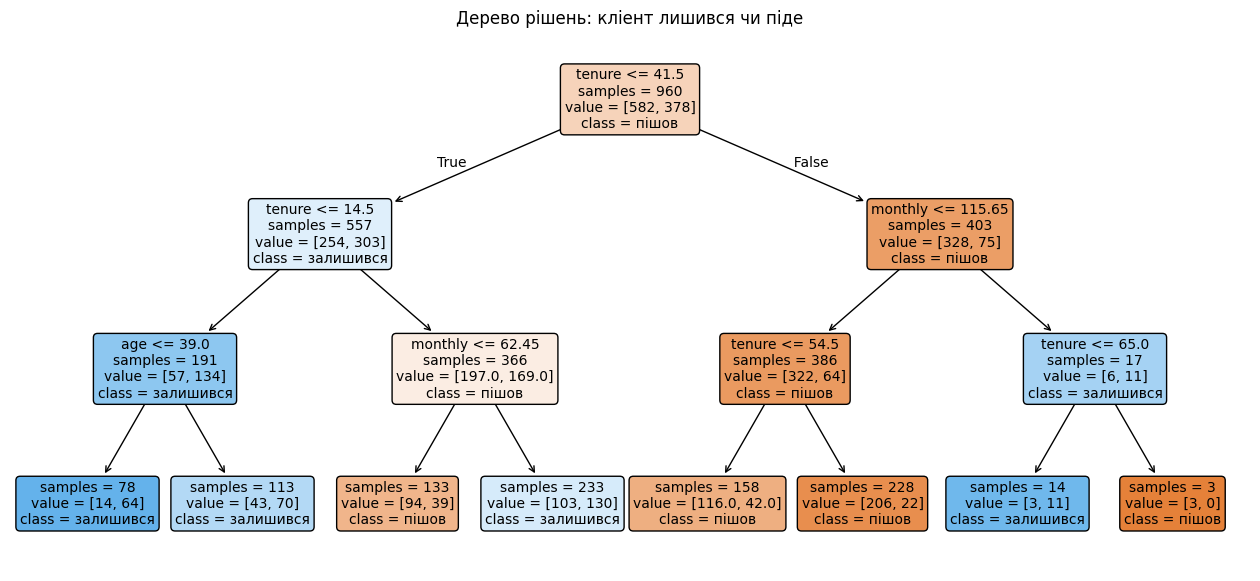

In [39]:
from sklearn.tree import plot_tree
plt.figure(figsize=(16, 7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['пішов','залишився'],
    filled=True, rounded=True, fontsize=10,impurity=False

)

plt.title("Дерево рішень: кліент лишився чи піде")
plt.show()

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy = {acc:.2%}\n")

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=["Насправді залишилися","Насправді пішли"],
    columns=["Передбачено залишилися", "Передбачено пішли"]
)
print("Матриця плутанини:")
display(df_cm)
print("\nДетальний звіт:")
print(classification_report(y_test, y_pred, target_names=["Залишилися","Пішли"]))

Accuracy = 59.17%

Матриця плутанини:


,Передбачено залишилися,Передбачено пішли
Насправді залишилися,85,61
Насправді пішли,37,57



Детальний звіт:
              precision    recall  f1-score   support

  Залишилися       0.70      0.58      0.63       146
       Пішли       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240

